In [3]:
import os
from dotenv import load_dotenv
from typing import List, Annotated
from pydantic import BaseModel

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
load_dotenv()

USER_AGENT environment variable not set, consider setting it to identify your requests.


True

In [4]:
urls=[
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]

docs=[WebBaseLoader(url).load() for url in urls]
docs


[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]]

In [5]:
docs

[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]]

In [6]:
doc_list=[items for sublist in docs for items in sublist]

In [7]:
doc_list

[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n'),
 Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n'),
 Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]

In [8]:
docs[0]

[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]

In [9]:
text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=100)
doc_splits=text_splitter.split_documents(doc_list)

In [10]:
vector_store=FAISS.from_documents(documents=doc_splits,embedding=OpenAIEmbeddings(model="text-embedding-3-small"))
retriever=vector_store.as_retriever()

In [11]:
retriever.invoke("What is LangGraph?")

[Document(id='5bdc9268-473e-4b86-892b-3f2830ed9360', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='e610d1ae-07db-4846-bf00-8e10bc48065c', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='9f89fc81-c299-4d64-a3cb-82ea1f09586b', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

In [12]:
from langchain_core.tools.retriever import create_retriever_tool

In [13]:
retriever_tool=create_retriever_tool(retriever,"retriever_db_blog","Search and run information about LangGraph")

In [14]:
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel Context Prot

In [15]:
docs_list = [item for sublist in docs for item in sublist]
doc_splits = text_splitter.split_documents(docs_list)
vectorstorelangchain=FAISS.from_documents(documents=doc_splits,embedding=OpenAIEmbeddings(model="text-embedding-3-small"))
retrieverlangchain=vectorstorelangchain.as_retriever()
retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [16]:
tools=[retriever_tool,retriever_tool_langchain]

In [23]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages

In [24]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

In [19]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
llm=init_chat_model("openai:gpt-4o-mini")

In [26]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = llm
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [34]:
from langsmith import Client
client = Client()
prompt = client.pull_prompt("hwchase17/react")

In [35]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

In [37]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = llm

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [ ]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = client.pull_prompt("rlm/rag-prompt")

    # LLM

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [39]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    response = llm.invoke(msg)
    return {"messages": [response]}

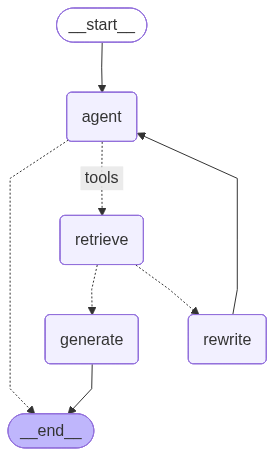

In [40]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [41]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---
---CHECK RELEVANCE---


c:\Users\kumar\Desktop\anaco\envs\agentic\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=grade(binary_score='no'), input_type=grade])
  return self.__pydantic_serializer__.to_python(


---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NO

KeyboardInterrupt: 

In [31]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

class AgentState(TypedDict):
    messages: List[BaseMessage]
    retry_count: int

# ---------------- AGENT NODE ----------------
def agent(state: AgentState):
    print("\n---CALL AGENT---")
    messages = state["messages"]

    model = llm.bind_tools(tools)
    response = model.invoke(messages)

    return {"messages": [response]}


# ---------------- GRADE DOCUMENTS ----------------
def grade_documents(state):
    print("\n---CHECK RELEVANCE---")

    class Grade(BaseModel):
        binary_score: str = Field(description="yes or no")

    grader_llm = llm.with_structured_output(Grade)

    prompt = PromptTemplate(
        template="""
You are a grader deciding whether retrieved documents are relevant.

Document:
{context}

Question:
{question}

Answer only yes or no.
""",
        input_variables=["context", "question"],
    )

    chain = prompt | grader_llm

    messages = state["messages"]
    question = messages[-3].content

    tool_message = messages[-1]

    if hasattr(tool_message, "artifact") and tool_message.artifact:
        docs = tool_message.artifact
    else:
        docs = tool_message.content

    # SAFE FORMAT
    def format_docs(docs):
        formatted = []
        for doc in docs:
            if hasattr(doc, "page_content"):
                formatted.append(doc.page_content)
            else:
                formatted.append(str(doc))
        return "\n\n".join(formatted)

    context = format_docs(docs)

    result = chain.invoke({"question": question, "context": context})
    score = result.binary_score.lower()

    print("RELEVANCE:", score)

    if score == "yes":
        return "generate"
    else:
        return "rewrite"
# ---------------- GENERATE ANSWER ----------------
def generate(state: AgentState):
    print("\n---GENERATE ANSWER---")

    messages = state["messages"]
    question = messages[-1].content

    # Tool message is previous message
    tool_message = messages[-2]

    # Extract docs safely
    if hasattr(tool_message, "artifact") and tool_message.artifact:
        docs = tool_message.artifact
    else:
        docs = tool_message.content

    # Format docs safely
    def format_docs(docs):
        formatted = []
        for doc in docs:
            if hasattr(doc, "page_content"):
                formatted.append(doc.page_content)
            else:
                formatted.append(str(doc))
        return "\n\n".join(formatted)

    context = format_docs(docs)

    rag_prompt = PromptTemplate(
        template="""
Use the context below to answer the question.

Context:
{context}

Question:
{question}

Answer:
""",
        input_variables=["context", "question"],
    )

    rag_chain = rag_prompt | llm | StrOutputParser()

    response = rag_chain.invoke({"context": context, "question": question})

    return {"messages": [AIMessage(content=response)]}

# ---------------- REWRITE QUERY ----------------
def rewrite(state: AgentState):
    print("\n---REWRITE QUERY---")

    messages = state["messages"]
    question = messages[-1].content

    rewrite_prompt = HumanMessage(
        content=f"""
Rewrite this question to improve document retrieval:

Original question:
{question}

Improved search query:
"""
    )

    response = llm.invoke([rewrite_prompt])

    return {"messages": [response]}


# ---------------- BUILD GRAPH ----------------
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)
workflow.add_node("retrieve", ToolNode([retriever_tool, retriever_tool_langchain]))
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)

workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {
        "generate": "generate",
        "rewrite": "rewrite",
    },
)

workflow.add_edge("rewrite", "agent")
workflow.add_edge("generate", END)

graph = workflow.compile()

In [32]:
result = graph.invoke(
    {"messages": [HumanMessage(content="What is LangGraph?")],
     "retry_count": 0},
    config={"recursion_limit": 10}
)

print(result["messages"][-1].content)


---CALL AGENT---

---CHECK RELEVANCE---


IndexError: list index out of range

In [33]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, ToolMessage
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# ---------------- STATE ----------------
class AgentState(TypedDict):
    messages: List[BaseMessage]
    retry_count: int


# ---------------- HELPERS ----------------
def get_last_user_question(messages):
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            return msg.content
    return ""


def get_last_tool_docs(messages):
    for msg in reversed(messages):
        if isinstance(msg, ToolMessage):
            if hasattr(msg, "artifact") and msg.artifact:
                return msg.artifact
            return msg.content
    return []


def format_docs(docs):
    formatted = []
    for doc in docs:
        if hasattr(doc, "page_content"):
            formatted.append(doc.page_content)
        else:
            formatted.append(str(doc))
    return "\n\n".join(formatted)


# ---------------- AGENT ----------------
def agent(state: AgentState):
    print("\n---CALL AGENT---")
    messages = state["messages"]

    model = llm.bind_tools(tools)
    response = model.invoke(messages)

    return {"messages": [response]}


# ---------------- GRADE ----------------
def grade_documents(state: AgentState):
    print("\n---CHECK RELEVANCE---")

    retry_count = state.get("retry_count", 0)

    class Grade(BaseModel):
        binary_score: str = Field(description="yes or no")

    grader_llm = llm.with_structured_output(Grade)

    prompt = PromptTemplate(
        template="""
You are a grader deciding whether retrieved documents are relevant.

Document:
{context}

Question:
{question}

Answer only yes or no.
""",
        input_variables=["context", "question"],
    )

    chain = prompt | grader_llm

    messages = state["messages"]
    question = get_last_user_question(messages)
    docs = get_last_tool_docs(messages)
    context = format_docs(docs)

    result = chain.invoke({"question": question, "context": context})
    score = result.binary_score.lower()

    print("RELEVANCE:", score)
    print("RETRY COUNT:", retry_count)

    # Force generate after 2 retries
    if retry_count >= 2:
        print("---FORCE GENERATE---")
        return "generate"

    if score == "yes":
        return "generate"
    else:
        state["retry_count"] = retry_count + 1
        return "rewrite"


# ---------------- GENERATE ----------------
def generate(state: AgentState):
    print("\n---GENERATE ANSWER---")

    messages = state["messages"]
    question = get_last_user_question(messages)
    docs = get_last_tool_docs(messages)
    context = format_docs(docs)

    rag_prompt = PromptTemplate(
        template="""
Use the context below to answer the question.

Context:
{context}

Question:
{question}

Answer:
""",
        input_variables=["context", "question"],
    )

    rag_chain = rag_prompt | llm | StrOutputParser()
    response = rag_chain.invoke({"context": context, "question": question})

    return {"messages": [AIMessage(content=response)]}


# ---------------- REWRITE ----------------
def rewrite(state: AgentState):
    print("\n---REWRITE QUERY---")

    messages = state["messages"]
    question = get_last_user_question(messages)
    retry_count = state.get("retry_count", 0)

    rewrite_prompt = HumanMessage(
        content=f"""
Rewrite this question to improve document retrieval:

Original question:
{question}

Improved search query:
"""
    )

    response = llm.invoke([rewrite_prompt])

    return {
        "messages": [response],
        "retry_count": retry_count
    }


# ---------------- GRAPH ----------------
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)
workflow.add_node("retrieve", ToolNode([retriever_tool, retriever_tool_langchain]))
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)

workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {
        "generate": "generate",
        "rewrite": "rewrite",
    },
)

workflow.add_edge("rewrite", "agent")
workflow.add_edge("generate", END)

graph = workflow.compile()

In [34]:
from langchain_core.messages import HumanMessage

result = graph.invoke(
    {
        "messages": [HumanMessage(content="What is LangGraph?")],
        "retry_count": 0
    },
    config={"recursion_limit": 10}
)

print(result["messages"][-1].content)


---CALL AGENT---

---CHECK RELEVANCE---
RELEVANCE: no
RETRY COUNT: 0

---REWRITE QUERY---

---CALL AGENT---

---CHECK RELEVANCE---
RELEVANCE: no
RETRY COUNT: 0

---REWRITE QUERY---

---CALL AGENT---

---CHECK RELEVANCE---
RELEVANCE: no
RETRY COUNT: 0

---REWRITE QUERY---

---CALL AGENT---


GraphRecursionError: Recursion limit of 10 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT

In [35]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, ToolMessage
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# ---------------- STATE ----------------
class AgentState(TypedDict):
    messages: List[BaseMessage]
    retry_count: int


# ---------------- HELPERS ----------------
def get_last_user_question(messages):
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            return msg.content
    return ""


def get_last_tool_docs(messages):
    for msg in reversed(messages):
        if isinstance(msg, ToolMessage):
            if hasattr(msg, "artifact") and msg.artifact:
                return msg.artifact
            return msg.content
    return []


def format_docs(docs):
    formatted = []
    for doc in docs:
        if hasattr(doc, "page_content"):
            formatted.append(doc.page_content)
        else:
            formatted.append(str(doc))
    return "\n\n".join(formatted)


# ---------------- AGENT ----------------
def agent(state: AgentState):
    print("\n---CALL AGENT---")
    messages = state["messages"]

    model = llm.bind_tools(tools)
    response = model.invoke(messages)

    return {"messages": [response]}


# ---------------- GRADE DOCUMENTS ----------------
def grade_documents(state: AgentState):
    print("\n---CHECK RELEVANCE---")

    retry_count = state.get("retry_count", 0)

    class Grade(BaseModel):
        binary_score: str = Field(description="yes or no")

    grader_llm = llm.with_structured_output(Grade)

    prompt = PromptTemplate(
        template="""
You are a grader deciding whether retrieved documents are relevant.

Document:
{context}

Question:
{question}

Answer only yes or no.
""",
        input_variables=["context", "question"],
    )

    chain = prompt | grader_llm

    messages = state["messages"]
    question = get_last_user_question(messages)
    docs = get_last_tool_docs(messages)
    context = format_docs(docs)

    result = chain.invoke({"question": question, "context": context})
    score = result.binary_score.lower()

    print("RELEVANCE:", score)
    print("RETRY COUNT:", retry_count)

    if retry_count >= 2:
        print("---FORCE GENERATE---")
        return {"next": "generate", "retry_count": retry_count}

    if score == "yes":
        return {"next": "generate", "retry_count": retry_count}
    else:
        return {"next": "rewrite", "retry_count": retry_count + 1}


# ---------------- GENERATE ----------------
def generate(state: AgentState):
    print("\n---GENERATE ANSWER---")

    messages = state["messages"]
    question = get_last_user_question(messages)
    docs = get_last_tool_docs(messages)
    context = format_docs(docs)

    rag_prompt = PromptTemplate(
        template="""
Use the context below to answer the question.

Context:
{context}

Question:
{question}

Answer:
""",
        input_variables=["context", "question"],
    )

    rag_chain = rag_prompt | llm | StrOutputParser()
    response = rag_chain.invoke({"context": context, "question": question})

    return {"messages": [AIMessage(content=response)]}


# ---------------- REWRITE ----------------
def rewrite(state: AgentState):
    print("\n---REWRITE QUERY---")

    question = get_last_user_question(state["messages"])
    retry_count = state.get("retry_count", 0)

    rewrite_prompt = HumanMessage(
        content=f"""
Rewrite this question to improve document retrieval:

Original question:
{question}

Improved search query:
"""
    )

    response = llm.invoke([rewrite_prompt])

    return {
        "messages": [response],
        "retry_count": retry_count
    }


# ---------------- BUILD GRAPH ----------------
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)
workflow.add_node("retrieve", ToolNode([retriever_tool, retriever_tool_langchain]))
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "retrieve",
        END: END,
    },
)

workflow.add_conditional_edges(
    "retrieve",
    lambda state: grade_documents(state)["next"],
    {
        "generate": "generate",
        "rewrite": "rewrite",
    },
)

workflow.add_edge("rewrite", "agent")
workflow.add_edge("generate", END)

graph = workflow.compile()

In [36]:
from langchain_core.messages import HumanMessage

result = graph.invoke(
    {
        "messages": [HumanMessage(content="What is LangGraph?")],
        "retry_count": 0
    },
    config={"recursion_limit": 10}
)

print(result["messages"][-1].content)


---CALL AGENT---

---CHECK RELEVANCE---
RELEVANCE: no
RETRY COUNT: 0

---REWRITE QUERY---

---CALL AGENT---

---CHECK RELEVANCE---
RELEVANCE: no
RETRY COUNT: 0

---REWRITE QUERY---

---CALL AGENT---

---CHECK RELEVANCE---
RELEVANCE: no
RETRY COUNT: 0

---REWRITE QUERY---

---CALL AGENT---


GraphRecursionError: Recursion limit of 10 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT